In [7]:

%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\Katya\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 52.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ----------------------- ---------------- 21.5/36.5 MB 112.0 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 107.6 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 80.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\Katya\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.metrics import r2_score

plt.style.use('ggplot')
sns.set_style('whitegrid')
%matplotlib inline

In [9]:
df = pd.read_csv('data.csv')
print("Розмір датасету:", df.shape)
df.head()

Розмір датасету: (944, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,sem,GRADE
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,-2.302585,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,2.208274,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,2.493205,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,2.646175,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,2.406945,13


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      944 non-null    object 
 1   sex         944 non-null    object 
 2   age         944 non-null    int64  
 3   address     944 non-null    object 
 4   famsize     944 non-null    object 
 5   Pstatus     944 non-null    object 
 6   Medu        944 non-null    int64  
 7   Fedu        944 non-null    int64  
 8   Mjob        944 non-null    object 
 9   Fjob        944 non-null    object 
 10  reason      944 non-null    object 
 11  guardian    944 non-null    object 
 12  traveltime  944 non-null    int64  
 13  studytime   944 non-null    int64  
 14  failures    944 non-null    int64  
 15  schoolsup   944 non-null    object 
 16  famsup      944 non-null    object 
 17  paid        944 non-null    object 
 18  activities  944 non-null    object 
 19  nursery     944 non-null    o

In [11]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
sem           0
GRADE         0
dtype: int64

In [12]:
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'sem']
df[numeric_cols + ['GRADE']].describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,sem,GRADE
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,16.688559,2.636653,2.404661,1.507415,1.985169,0.253178,3.940678,3.192797,3.145127,1.475636,2.282839,3.527542,4.385593,2.284653,11.469280
std,1.204638,1.129181,1.098258,0.723744,0.832653,0.645147,0.907538,1.028188,1.137949,0.877091,1.268545,1.434791,6.331564,0.679939,3.794162
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-2.302585,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,2.208274,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,2.406945,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,2.572612,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,2.949688,20.000000


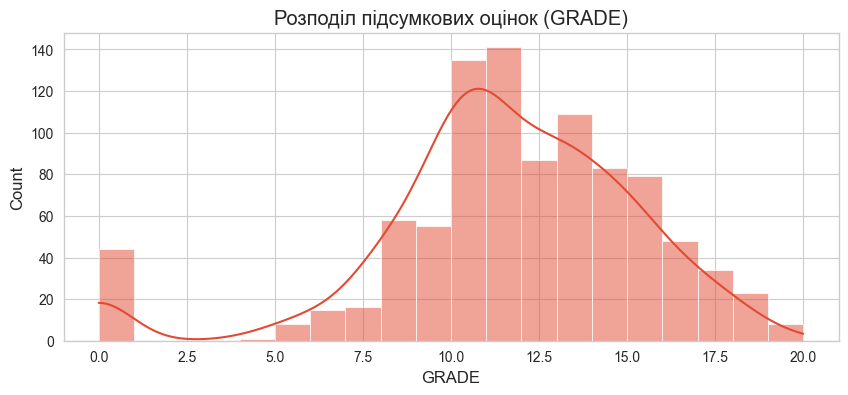

In [13]:
plt.figure(figsize=(10,4))
sns.histplot(df['GRADE'], bins=20, kde=True)
plt.title('Розподіл підсумкових оцінок (GRADE)')
plt.xlabel('GRADE')
plt.show()

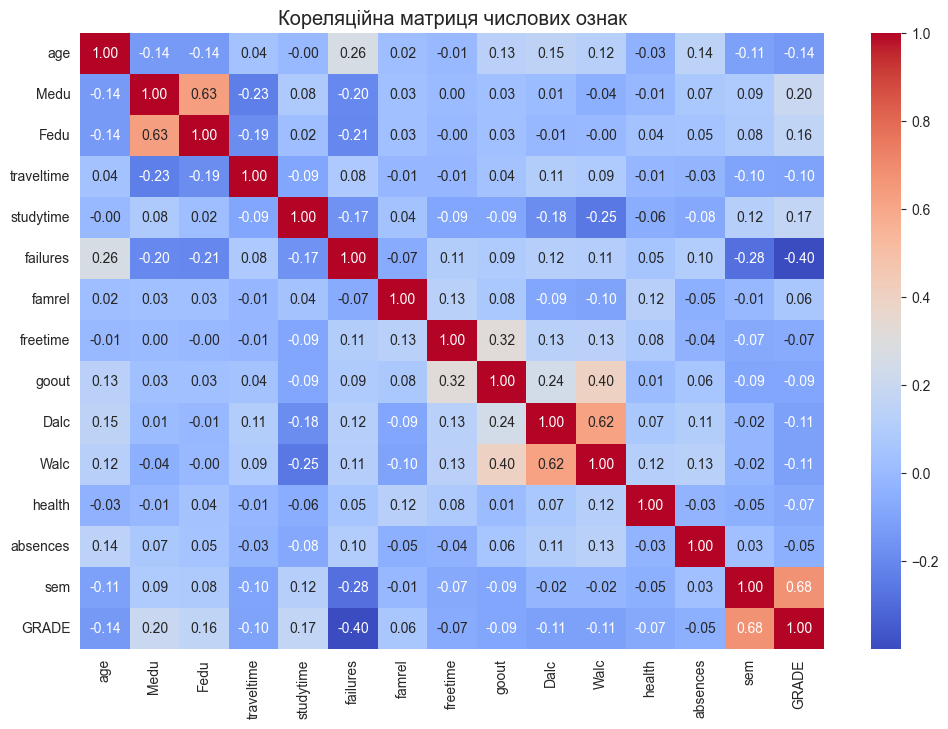

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols + ['GRADE']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Кореляційна матриця числових ознак')
plt.show()

In [15]:
X_num = df[numeric_cols]
y = df['GRADE']

X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: R² = {r2:.4f}")

LinearRegression: R² = 0.5270
Ridge: R² = 0.5270
Lasso: R² = 0.3878


In [17]:
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_cv = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
print(f"Ridge: alpha={ridge_cv.best_params_['alpha']}, R²(CV)={ridge_cv.best_score_:.4f}")

lasso_cv = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='r2')
lasso_cv.fit(X_train_scaled, y_train)
print(f"Lasso: alpha={lasso_cv.best_params_['alpha']}, R²(CV)={lasso_cv.best_score_:.4f}")

Ridge: alpha=10, R²(CV)=0.4927
Lasso: alpha=0.1, R²(CV)=0.4991


In [18]:
best_ridge = ridge_cv.best_estimator_
best_lasso = lasso_cv.best_estimator_

print(f"Ridge тест: R² = {r2_score(y_test, best_ridge.predict(X_test_scaled)):.4f}")
print(f"Lasso тест: R² = {r2_score(y_test, best_lasso.predict(X_test_scaled)):.4f}")

Ridge тест: R² = 0.5268
Lasso тест: R² = 0.5228


In [19]:
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 
                    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 
                    'nursery', 'higher', 'internet', 'romantic']
categorical_cols = [c for c in categorical_cols if c in df.columns]

numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'sem']

X_all = df[categorical_cols + numeric_cols]
y = df['GRADE']

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

models_all = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=10000),
    'SGDRegressor': SGDRegressor(loss='squared_error', max_iter=1000, random_state=42)
}

for name, model in models_all.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: R² = {r2:.4f}")

LinearRegression: R² = 0.5294
Ridge: R² = 0.5296
Lasso: R² = 0.3878
SGDRegressor: R² = 0.4973


In [21]:
param_grid_ridge = {'regressor__alpha': [0.01, 0.1, 1, 10, 100]}
ridge_pipe = Pipeline([('preprocessor', preprocessor), ('regressor', Ridge())])
ridge_gs = GridSearchCV(ridge_pipe, param_grid_ridge, cv=5, scoring='r2')
ridge_gs.fit(X_train, y_train)
print(f"Ridge: alpha={ridge_gs.best_params_['regressor__alpha']}, R²(CV)={ridge_gs.best_score_:.4f}")

param_grid_lasso = {'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_pipe = Pipeline([('preprocessor', preprocessor), ('regressor', Lasso(max_iter=10000))])
lasso_gs = GridSearchCV(lasso_pipe, param_grid_lasso, cv=5, scoring='r2')
lasso_gs.fit(X_train, y_train)
print(f"Lasso: alpha={lasso_gs.best_params_['regressor__alpha']}, R²(CV)={lasso_gs.best_score_:.4f}")

param_grid_sgd = {
    'regressor__alpha': [0.0001, 0.001, 0.01],
    'regressor__penalty': ['l2', 'l1', 'elasticnet'],
    'regressor__learning_rate': ['constant', 'optimal', 'invscaling']
}
sgd_pipe = Pipeline([('preprocessor', preprocessor), ('regressor', SGDRegressor(loss='squared_error', max_iter=1000, random_state=42))])
sgd_gs = GridSearchCV(sgd_pipe, param_grid_sgd, cv=3, scoring='r2', n_jobs=-1)
sgd_gs.fit(X_train, y_train)
print(f"SGD: best params={sgd_gs.best_params_}, R²(CV)={sgd_gs.best_score_:.4f}")

Ridge: alpha=100, R²(CV)=0.5065
Lasso: alpha=0.01, R²(CV)=0.5069
SGD: best params={'regressor__alpha': 0.01, 'regressor__learning_rate': 'invscaling', 'regressor__penalty': 'elasticnet'}, R²(CV)=0.4786


In [22]:
best_ridge_all = ridge_gs.best_estimator_
best_lasso_all = lasso_gs.best_estimator_
best_sgd_all = sgd_gs.best_estimator_

print(f"Ridge optimized test R²: {r2_score(y_test, best_ridge_all.predict(X_test)):.4f}")
print(f"Lasso optimized test R²: {r2_score(y_test, best_lasso_all.predict(X_test)):.4f}")
print(f"SGD optimized test R²: {r2_score(y_test, best_sgd_all.predict(X_test)):.4f}")

Ridge optimized test R²: 0.5252
Lasso optimized test R²: 0.5349
SGD optimized test R²: 0.5049


In [23]:
predict_df = pd.read_csv('predict.csv')
X_predict = predict_df[categorical_cols + numeric_cols]
best_model = best_ridge_all
predictions = best_model.predict(X_predict)
print("Прогнози (перші 5):", predictions[:5])

Прогнози (перші 5): [-2.86746177  9.56303553  9.83272497 10.8937446   7.90759618]


In [24]:
pd.Series(predictions).to_csv('predictions_reg.csv', index=False, header=False)
print("Файл predictions_reg.csv збережено.")

Файл predictions_reg.csv збережено.
